# Figures 3 & 4: Sea Ice-Chlorophyll Relationships in Antarctic Frontal Zones

## Purpose
These notebooks generate **Figures 3 and 4** for the GRL manuscript, examining:
- **Figure 3**: Time series of chlorophyll-*a* anomalies and lagged sea ice extent anomalies
- **Figure 4**: Scatter plot correlations between sea ice and chlorophyll-*a* across three frontal zones

## Data Sources

### 1. Sea Ice Extent Anomaly (SIEA)
- **Source**: NSIDC Sea Ice Index monthly data (1998-2023)
- **Processing**: Annual mean anomalies calculated relative to 1998-2023 climatology
- **Lag structure**: 1-year lag applied (year y-1 sea ice vs. year y chlorophyll)
- **Units**: 10⁶ km²

### 2. Chlorophyll-*a* Concentration
- **Source**: Copernicus GlobColour Level 3 merged satellite data (1998-2023)
- **Processing**: Monthly anomalies (deviation from monthly climatology)
- **Aggregation**: Annual means calculated from monthly anomalies
- **Regions analyzed**:
  - **PF-SACCF**: Polar Front to Southern ACC Front
  - **SACCF-SB**: Southern ACC Front to Southern Boundary
  - **SB-AntCoastline**: Southern Boundary to Antarctic coastline
- **Units**: mg m⁻³

## Methods Overview

### Lag Structure Rationale
- **1-year lag** accounts for delayed biological response to sea ice conditions
- Previous year's sea ice influences:
  - Water column stratification persistence
  - Iron availability from meltwater
  - Light conditions for subsequent growing season
- Tested multiple lag structures; 1-year lag shows strongest correlations

### Anomaly Calculations
**Sea ice extent anomalies:**
```
SIEA = Annual SIE - Climatological mean SIE
```

**Chlorophyll-*a* anomalies:**
```
Chl-a anomaly = Monthly Chl-a - Monthly climatological mean
Annual Chl-a anomaly = Mean(Monthly Chl-a anomalies)
```

### Statistical Analysis
- **Correlation method**: Spearman rank correlation (ρₛ)
  - Robust to non-linear monotonic relationships
  - Less sensitive to outliers than Pearson correlation
- **Regression**: Linear regression with 95% confidence intervals
- **Error bars**: Standard error of annual means

## Key Results

### Figure 3: Time Series Analysis

**Panel A - SB-AntCoastline:**
- Spearman ρₛ = 0.54, p < 0.01 (significant)
- Strongest positive relationship
- Clear coherence post-2015 decline

**Panel B - SACCF-SB:**
- Spearman ρₛ = 0.48, p < 0.05 (significant)
- Moderate positive correlation
- Notable 2015 regime shift

**Panel C - PF-SACCF:**
- Spearman ρₛ = 0.31, p = 0.12 (not significant)
- Weaker relationship in northernmost zone
- Higher natural variability

### Figure 4: Scatter Plot Correlations

**Common features across all zones:**
- Positive relationships between lagged SIEA and Chl-*a*
- Color-coded by year showing temporal evolution
- Pre-2015 (higher ice) vs. post-2015 (lower ice) clustering
- Regression lines with equations and R² values

**Regional differences:**
- **Strongest**: SB-AntCoastline (closest to ice edge)
- **Moderate**: SACCF-SB (intermediate zone)
- **Weakest**: PF-SACCF (northernmost, less ice influence)

## Ecological Interpretation

### Positive Correlations Suggest:
1. **Enhanced stratification**: More sea ice melt → stronger stratification → better light conditions
2. **Iron fertilization**: Ice-associated iron released during melt
3. **Habitat provision**: Sea ice edge as productive zone
4. **Extended growing season**: Earlier ice retreat → longer productive period

### 2015 Regime Shift:
- Rapid sea ice decline after 2015
- Concurrent chlorophyll-*a* decreases in ice-proximal zones
- Suggests ice-related nutrients/habitat critical for productivity

## Statistical Notes
- **Spearman correlation** preferred over Pearson due to:
  - Non-normal data distributions
  - Potential non-linear relationships
  - Robustness to outliers
- **Standard errors** show uncertainty in annual means
- **P-values < 0.05** indicate significant relationships

## Outputs
- **Figure_3.png**: Three-panel time series (300 DPI)
- **Figure_4.png**: Three-panel scatter plots (300 DPI)
- Both figures show relationship strength decreasing with distance from Antarctic margin

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sie=pd.read_csv("/A04/so_data/ubuntu/Chapter_2/SIEA_1998_2023.csv")
sie.set_index('time', inplace=True)

<>:18: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_1044566/4128219578.py:18: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')


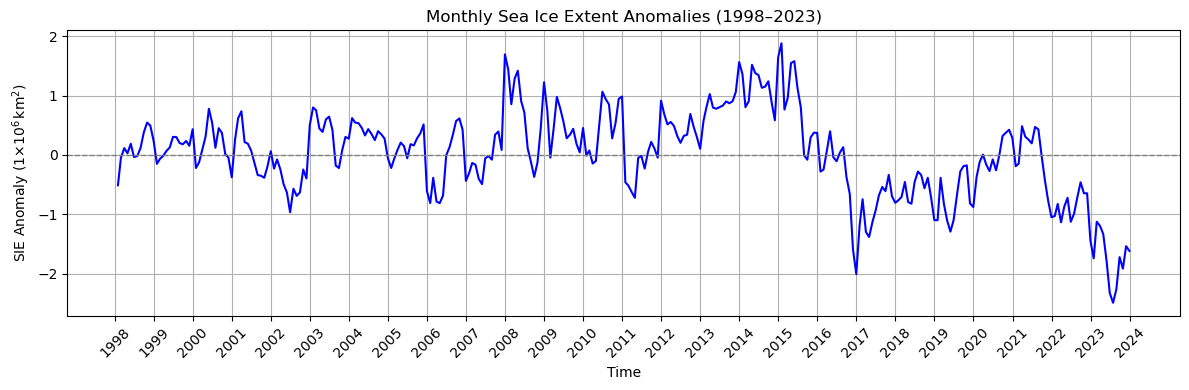

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
# Plotting
sie.index = pd.to_datetime(sie.index)
plt.figure(figsize=(12, 4))  # Set the figure size for better readability
plt.plot(sie.index, sie['SIEA'], label='SIEA', color='blue')  # Plot SIEA over time
plt.axhline(0, color='grey', linewidth=1, linestyle='--')
# Generate x-ticks for each year in the dataset's range
start_year = sie.index.year.min()-1
end_year = sie.index.year.max()+1
years = pd.date_range(start=f'{start_year}-01-31', end=f'{end_year}-12-31', freq='YS')

plt.xticks(years, [year.strftime('%Y') for year in years], rotation=45)  # Set x-ticks to each year

# Additional plot settings
plt.title('Monthly Sea Ice Extent Anomalies (1998–2023)')  # Title of the plot
plt.xlabel('Time')  # Label for the x-axis
plt.ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')
#plt.legend()  # Show legend
plt.tight_layout()  # Adjust layout to not cut off labels
plt.grid()
plt.show()  # Display the plot

<>:14: SyntaxWarning: invalid escape sequence '\,'
<>:14: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_1044566/3552723640.py:14: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')
/tmp/ipykernel_1044566/3552723640.py:4: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  df_annual = sie.resample('AS').mean()


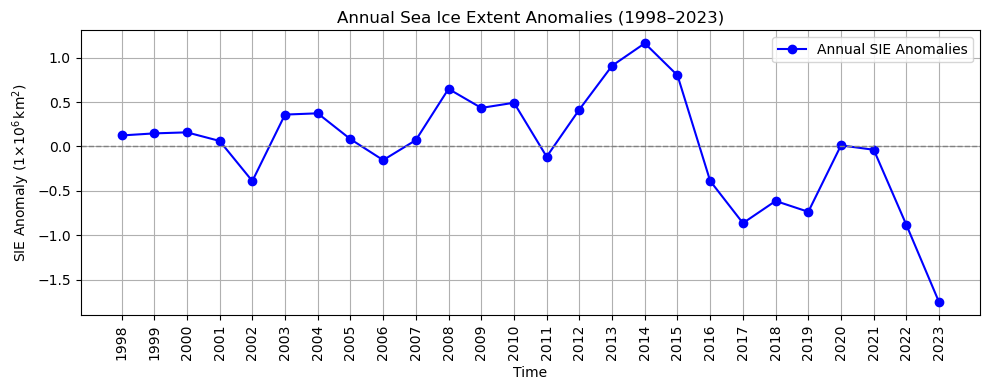

In [4]:
sie.index = pd.to_datetime(sie.index)

# Calculate the annual average of all columns
df_annual = sie.resample('AS').mean()
plt.figure(figsize=(10, 4))
plt.plot(df_annual.index, df_annual.SIEA, label='Annual SIE Anomalies', marker='o', color='blue')
plt.axhline(0, color='grey', linewidth=1, linestyle='--')
years = pd.date_range(start='1997-01-31', end='2023-12-31', freq='YS')
plt.xticks(years, [year.strftime('%Y') for year in years], rotation=90)  # Set x-ticks to each year

# Additional plot settings
plt.title('Annual Sea Ice Extent Anomalies (1998–2023)')  # Title of the plot
plt.xlabel('Time')  # Label for the x-axis
plt.ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')
plt.legend()  # Show legend
plt.grid()
plt.tight_layout()  # Adjust layout to not cut off labels
plt.show()

In [5]:
df_annual['SIEA_shifted'] = df_annual['SIEA'].shift(1)
df_annual

,extent,area,SIEA,SIEA_shifted
time,,,,
1998-01-01,11.689167,8.814167,0.123696,NaN
1999-01-01,11.712500,8.829167,0.147030,0.123696
2000-01-01,11.724167,8.995000,0.158696,0.147030
2001-01-01,11.627500,8.724167,0.062030,0.158696
2002-01-01,11.175833,8.505000,-0.389637,0.062030
2003-01-01,11.924167,9.066667,0.358696,-0.389637
2004-01-01,11.938333,9.047500,0.372863,0.358696
2005-01-01,11.647500,8.752500,0.082030,0.372863
2006-01-01,11.411667,8.667500,-0.153804,0.082030


In [6]:
chl=pd.read_csv("/A04/so_data/Revised_data/file_L3_2023_nb.csv")
chl

,time,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean,PF_AntCoastline
0,31/01/1998,0.216398,0.224614,0.208406,0.249688,0.260803,0.496370,0.326782,0.387126
1,28/02/1998,0.218153,0.200553,0.162206,0.183465,0.210515,0.435724,0.277568,0.327136
2,31/03/1998,0.206011,0.204145,0.156548,0.155480,0.189952,0.294024,0.216499,0.235465
3,30/04/1998,0.199581,0.191527,0.157928,0.155041,0.157428,0.204129,0.176325,0.177281
4,31/05/1998,0.172245,0.170177,0.147406,0.139465,0.141889,0.151725,0.153198,0.142116
...,...,...,...,...,...,...,...,...,...
307,31/08/2023,0.160348,0.147546,0.148140,0.150953,0.170122,0.206183,0.156286,0.166817
308,30/09/2023,0.191858,0.174154,0.154787,0.153830,0.159733,0.153467,0.159362,0.154703
309,31/10/2023,0.274263,0.246151,0.186206,0.178126,0.174896,0.176384,0.194722,0.176966
310,30/11/2023,0.296175,0.266264,0.296966,0.306150,0.239961,0.234622,0.270200,0.262909


In [7]:
chl['time'] = pd.to_datetime(chl['time'])  # Convert column to datetime
chl.set_index('time', inplace=True)  # Set it as index

/tmp/ipykernel_1044566/3072798959.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  chl['time'] = pd.to_datetime(chl['time'])  # Convert column to datetime


In [8]:
chlorophyll_df = chl.resample('A').mean()  # 'A' means annual resampling
chlorophyll_df

/tmp/ipykernel_1044566/179875448.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  chlorophyll_df = chl.resample('A').mean()  # 'A' means annual resampling


,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean,PF_AntCoastline
time,,,,,,,,
1998-12-31,0.194513,0.191040,0.171704,0.190773,0.206059,0.276036,0.213140,0.232386
1999-12-31,0.196223,0.201737,0.180434,0.196529,0.215683,0.276024,0.220812,0.238428
2000-12-31,0.190666,0.191125,0.174018,0.196950,0.230030,0.297693,0.224488,0.250712
2001-12-31,0.198790,0.197341,0.175326,0.200967,0.234187,0.295024,0.224422,0.248639
2002-12-31,0.197043,0.195447,0.170773,0.185730,0.222261,0.280613,0.216135,0.236802
2003-12-31,0.232318,0.211638,0.183246,0.201974,0.228384,0.285755,0.229087,0.247223
2004-12-31,0.220703,0.213823,0.188148,0.202660,0.222034,0.302131,0.235467,0.254437
2005-12-31,0.220115,0.209735,0.179819,0.205250,0.245707,0.299219,0.235079,0.259168
2006-12-31,0.219370,0.205934,0.183144,0.205058,0.242853,0.300720,0.236722,0.260822


In [9]:
chlorophyll_df = chlorophyll_df.reset_index().rename(columns={'time': 'Date'})
chlorophyll_df

,Date,40S-NB,NB_SAF,SAF_PF,PF_SACCF,SACCF_SB,SB_AntCoastline,Southern Ocean,PF_AntCoastline
0,1998-12-31,0.194513,0.191040,0.171704,0.190773,0.206059,0.276036,0.213140,0.232386
1,1999-12-31,0.196223,0.201737,0.180434,0.196529,0.215683,0.276024,0.220812,0.238428
2,2000-12-31,0.190666,0.191125,0.174018,0.196950,0.230030,0.297693,0.224488,0.250712
3,2001-12-31,0.198790,0.197341,0.175326,0.200967,0.234187,0.295024,0.224422,0.248639
4,2002-12-31,0.197043,0.195447,0.170773,0.185730,0.222261,0.280613,0.216135,0.236802
5,2003-12-31,0.232318,0.211638,0.183246,0.201974,0.228384,0.285755,0.229087,0.247223
6,2004-12-31,0.220703,0.213823,0.188148,0.202660,0.222034,0.302131,0.235467,0.254437
7,2005-12-31,0.220115,0.209735,0.179819,0.205250,0.245707,0.299219,0.235079,0.259168
8,2006-12-31,0.219370,0.205934,0.183144,0.205058,0.242853,0.300720,0.236722,0.260822
9,2007-12-31,0.227653,0.215310,0.190365,0.203570,0.231920,0.278506,0.229078,0.244828


<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:17: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_1044566/2976627623.py:17: SyntaxWarning: invalid escape sequence '\,'
  ax2.set_ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')


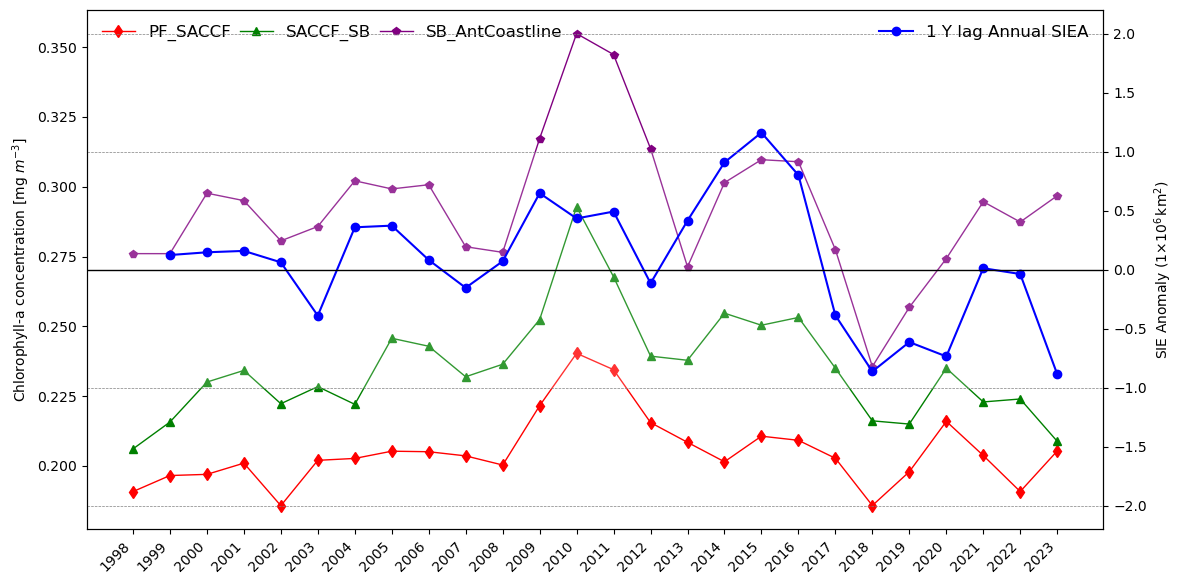

In [10]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))
# ax1.plot(chlorophyll_df['Date'], chlorophyll_df['NB_SAF'], marker='o', color= 'blue', linestyle='-', label='NB_SAF', linewidth=1)
# ax1.plot(chlorophyll_df['Date'], chlorophyll_df['SAF_PF'], marker='s', linestyle='-', color= 'orange', label='SAF_PF', linewidth=1)
ax1.plot(chlorophyll_df['Date'], chlorophyll_df['PF_SACCF'], marker='d', linestyle='-', color='red', label='PF_SACCF',linewidth=1)
ax1.plot(chlorophyll_df['Date'], chlorophyll_df['SACCF_SB'], marker='^', linestyle='-', color= 'green', label='SACCF_SB', linewidth=1)
ax1.plot(chlorophyll_df['Date'], chlorophyll_df['SB_AntCoastline'], marker='p', linestyle='-', color='purple', label='SB_AntCoastline', linewidth=1)
# ax1.plot(chlorophyll_df['Date'], chlorophyll_df['30S-NB'], marker='8', linestyle='-', color='violet', label='30S-NB', linewidth=1)

ax1.set_ylabel('Chlorophyll-a concentration [mg $m^{-3}$]')
ax1.legend(ncol=4, loc='upper left', columnspacing=0.5, labelspacing=0.5, fontsize=12, frameon=False)
# Secondary y-axis (right)
ax2 = ax1.twinx()
ax2.plot(chlorophyll_df['Date'], df_annual.SIEA_shifted, label='1 Y lag Annual SIEA', color='blue', marker="o")
#ax2.plot(chlorophyll_df['Date'], df_annual.SIEA_MA5, label='5 MA Annual SIE Anomalies', color='cyan', marker="o")
ax2.set_ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')
ax2.tick_params(axis='y')
ax2.legend(loc='upper right')

plt.grid(False)
plt.axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=-1, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=2, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=-2, color='gray', linestyle='--', linewidth=0.5)
plt.axhspan(-1, 1, facecolor='white', alpha=0.2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.legend(ncol=3, loc='upper right', fontsize=12, frameon=False)
#
# Convert the DatetimeIndex to a list
years = range(1998, 2024, 1)
subset_ticks = chlorophyll_df['Date']
plt.xticks(ticks=subset_ticks, labels=years)
fig.autofmt_xdate(rotation=45)

# Plot formatting
plt.rcParams['font.family'] = 'Serif'
plt.rcParams['font.size'] = 12
plt.tight_layout()

<>:18: SyntaxWarning: invalid escape sequence '\,'
<>:18: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_1044566/3513535754.py:18: SyntaxWarning: invalid escape sequence '\,'
  axes[plot_idx].set_xlabel('Annual SIEA ($1 \u00D7 10^6 \, \mathrm{km}^2$) (y+1)')


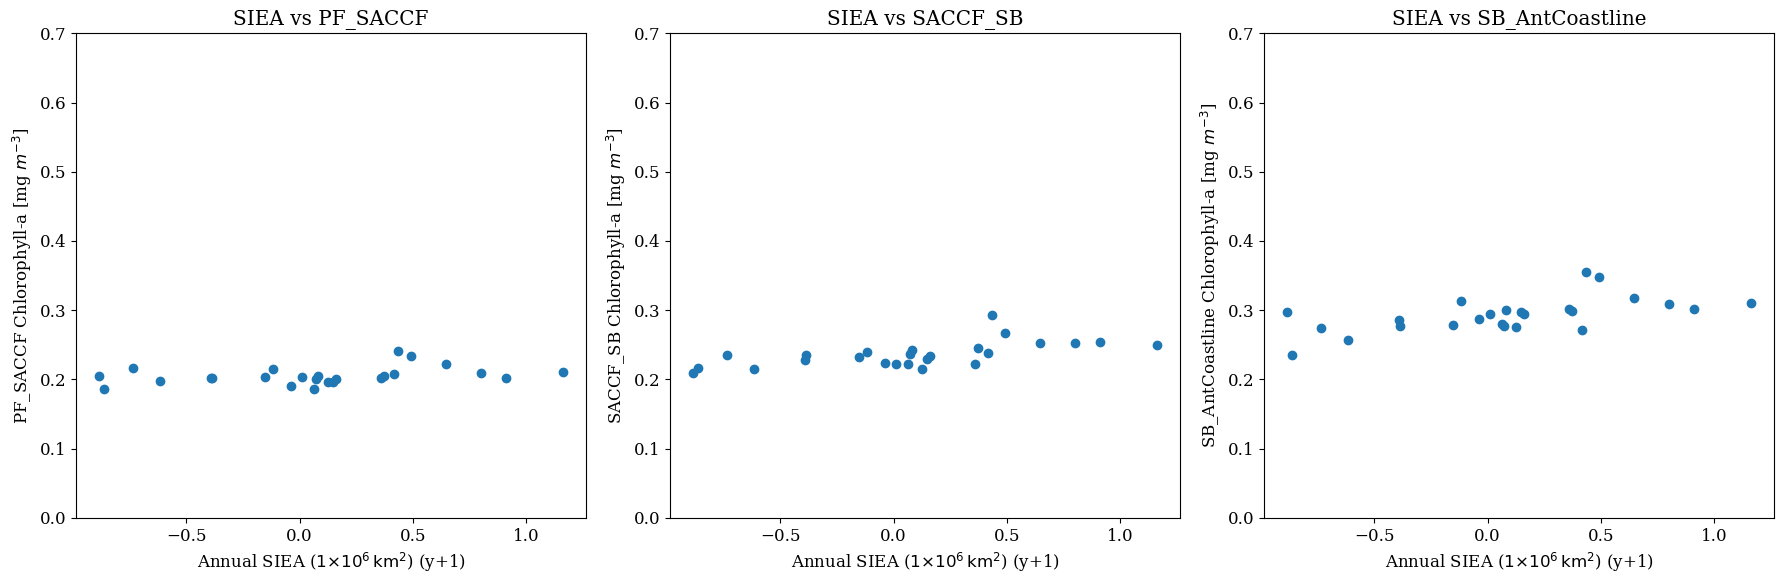

In [11]:
import matplotlib.pyplot as plt

# Define the columns you want to plot
columns_to_plot = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']

# Create subplots for the selected columns
num_plots = len(columns_to_plot)
num_rows = (num_plots + 2) // 3  # 3 plots per row

# Create the subplots
fig, axes = plt.subplots(num_rows, 3, figsize=(18, 6 * num_rows))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration

# Plot each selected column
plot_idx = 0
for column in columns_to_plot:
    axes[plot_idx].scatter(df_annual['SIEA'].shift(1), chlorophyll_df[column], label=column)
    axes[plot_idx].set_xlabel('Annual SIEA ($1 \u00D7 10^6 \, \mathrm{km}^2$) (y+1)')
    axes[plot_idx].set_ylabel(f'{column} Chlorophyll-a [mg $m^{{-3}}$]')
    axes[plot_idx].set_title(f'SIEA vs {column}')
    axes[plot_idx].set_ylim(0, 0.7)
    # axes[plot_idx].legend()
    plot_idx += 1

# Hide any unused subplots
for j in range(plot_idx, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [12]:
chl=pd.read_csv("/A04/so_data/Revised_data/file_L3_2023_nb.csv")
chl['time']= pd.to_datetime(chl['time'])

/tmp/ipykernel_1044566/3671706676.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  chl['time']= pd.to_datetime(chl['time'])


In [13]:
# Step 1: Extract month from 'time' column
chl['month'] = chl['time'].dt.month

# Define the variables for which to calculate anomalies
variables = ['PF_SACCF', 'SACCF_SB', 'SB_AntCoastline']

# Calculate anomalies for each variable
for var in variables:
    # Step 2: Group by month and calculate the mean for each month
    monthly_climatology = chl.groupby('month')[var].mean()
    
    # Step 3: Subtract the monthly climatology from the variable to produce anomalies
    chl[f'{var}_ano'] = chl.apply(lambda row: row[var] - monthly_climatology[row['month']], axis=1)

# Optionally, drop the 'month' column if it's no longer needed
chl.drop('month', axis=1, inplace=True)

# Display the DataFrame with the new anomaly columns
print(chl)

          time    40S-NB    NB_SAF    SAF_PF  PF_SACCF  SACCF_SB  \
0   1998-01-31  0.216398  0.224614  0.208406  0.249688  0.260803   
1   1998-02-28  0.218153  0.200553  0.162206  0.183465  0.210515   
2   1998-03-31  0.206011  0.204145  0.156548  0.155480  0.189952   
3   1998-04-30  0.199581  0.191527  0.157928  0.155041  0.157428   
4   1998-05-31  0.172245  0.170177  0.147406  0.139465  0.141889   
..         ...       ...       ...       ...       ...       ...   
307 2023-08-31  0.160348  0.147546  0.148140  0.150953  0.170122   
308 2023-09-30  0.191858  0.174154  0.154787  0.153830  0.159733   
309 2023-10-31  0.274263  0.246151  0.186206  0.178126  0.174896   
310 2023-11-30  0.296175  0.266264  0.296966  0.306150  0.239961   
311 2023-12-31  0.287029  0.330389  0.336561  0.347688  0.290151   

     SB_AntCoastline  Southern Ocean  PF_AntCoastline  PF_SACCF_ano  \
0           0.496370        0.326782         0.387126     -0.007562   
1           0.435724        0.277568     

In [14]:
chl.set_index('time', inplace=True)

In [15]:
chl.index = pd.to_datetime(chl.index)

# Calculate the annual average of all columns
chl_annual = chl.resample('A').mean()

/tmp/ipykernel_1044566/3620744891.py:4: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  chl_annual = chl.resample('A').mean()


<>:23: SyntaxWarning: invalid escape sequence '\,'
<>:23: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_1044566/1363146177.py:23: SyntaxWarning: invalid escape sequence '\,'
  ax2.set_ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')


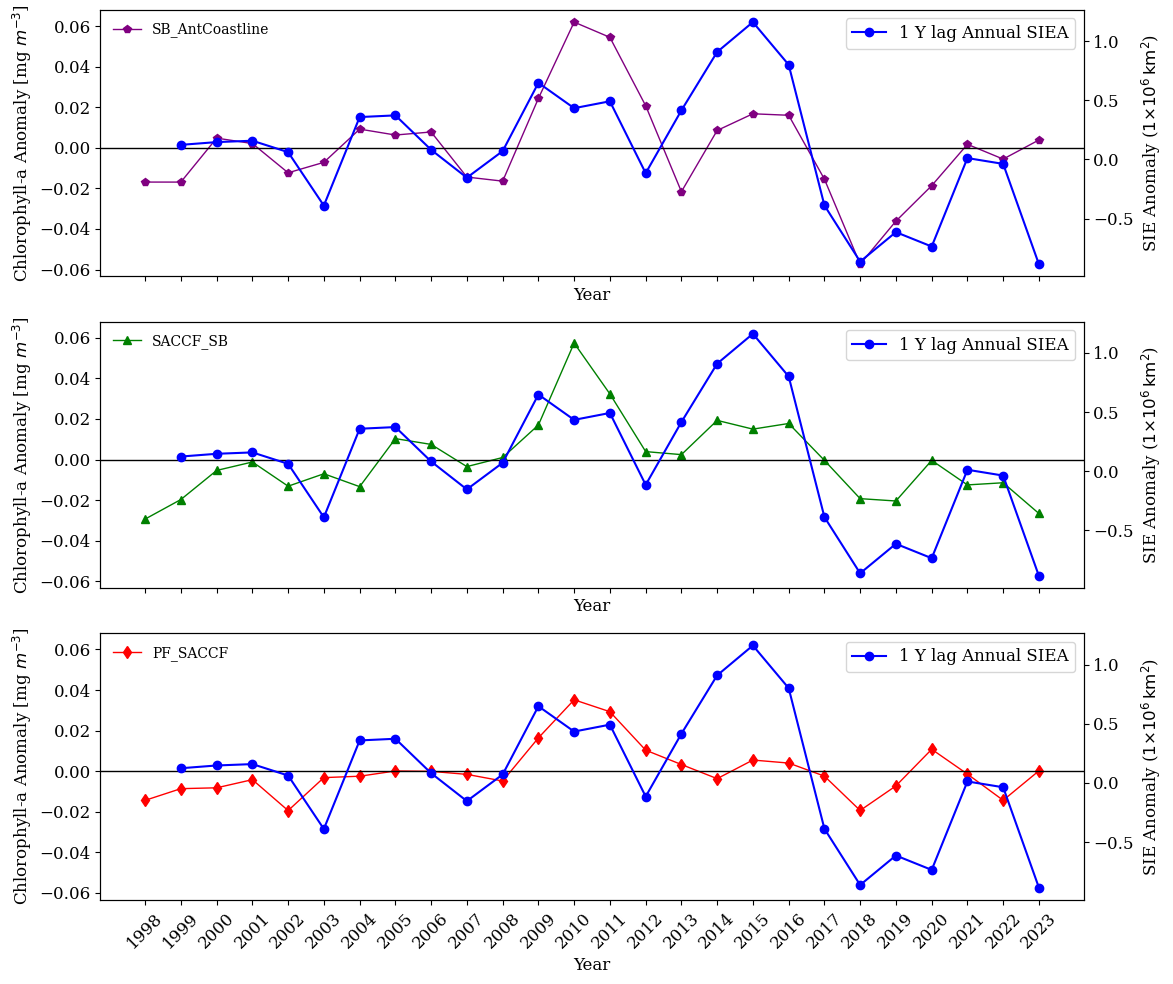

In [16]:
import matplotlib.pyplot as plt

# Create a figure with three subplots in one row
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True, sharex=True)
# Plot each subplot
anomaly_vars = ['SB_AntCoastline_ano', 'SACCF_SB_ano', 'PF_SACCF_ano']
colors = ['purple', 'green', 'red']
markers = ['p', '^', 'd']
labels = ['SB_AntCoastline', 'SACCF_SB', 'PF_SACCF']

for i, (ax, anomaly_var, color, marker, label) in enumerate(zip(axes, anomaly_vars, colors, markers, labels)):
    ax.plot(chl_annual.index, chl_annual[anomaly_var], marker=marker, linestyle='-', color=color, label=label, linewidth=1)
    
    ax.set_ylabel('Chlorophyll-a Anomaly [mg $m^{-3}$]')
    ax.set_xlabel('Year')
    ax.legend(loc='upper left', fontsize=10, frameon=False)
    ax.grid(False)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    # Add secondary y-axis for SIEA
    ax2 = ax.twinx()
    ax2.plot(chl_annual.index, df_annual.SIEA_shifted, label='1 Y lag Annual SIEA', color='blue', marker="o")
    ax2.set_ylabel('SIE Anomaly ($1 \u00D7 10^6 \, \mathrm{km}^2$)')
    ax2.tick_params(axis='y')
    ax2.legend(loc='upper right')
    
    # Format x-axis
    subset_ticks = chl_annual.index
    ax.set_xticks(subset_ticks)
    ax.set_xticklabels(range(1998, 2024, 1), rotation=45)

# Global plot formatting
plt.tight_layout()
plt.show()

In [17]:
chl_annual_1=chl_annual.iloc[1:]
df_annual_1 = df_annual.iloc[1:]

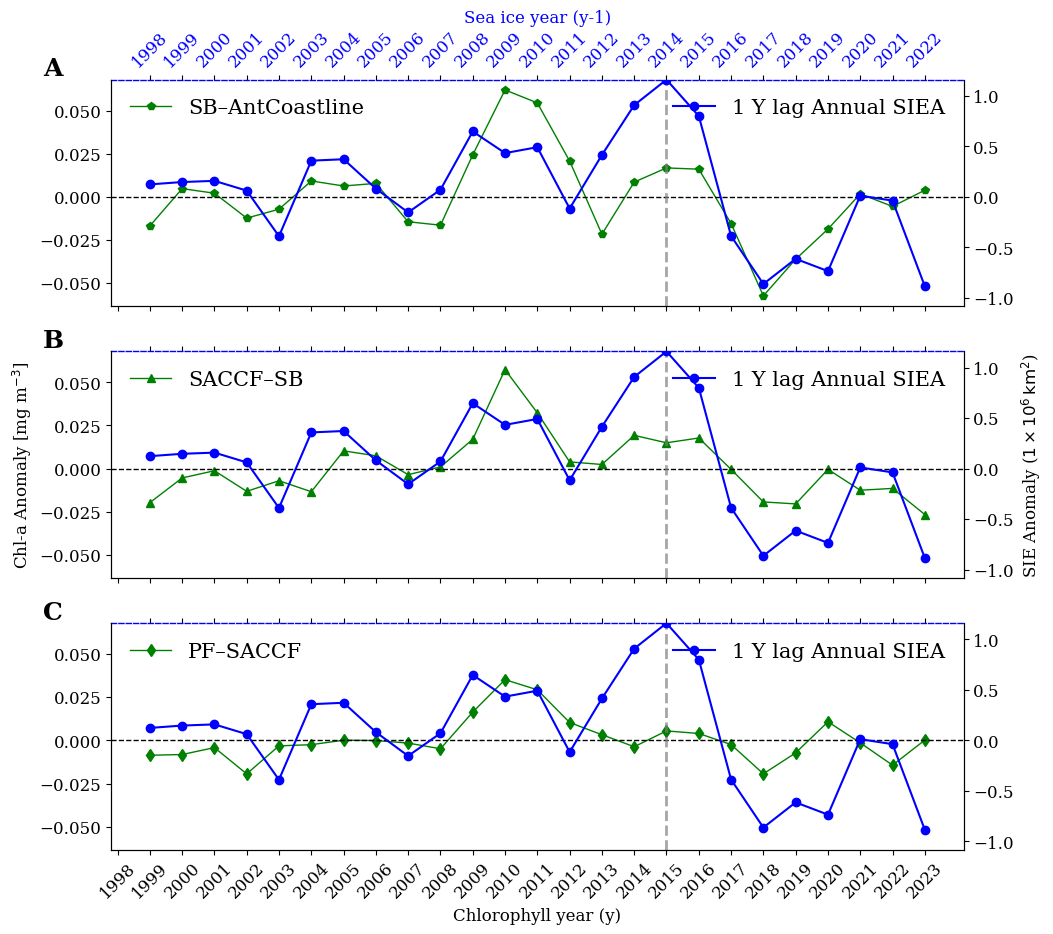

In [18]:
import matplotlib.pyplot as plt

# Create a figure with three subplots in one row
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharey=True, sharex=True)

# Variables
anomaly_vars = ['SB_AntCoastline_ano', 'SACCF_SB_ano', 'PF_SACCF_ano']
colors = ['green', 'green', 'green']
markers = ['p', '^', 'd']
labels = ['SB–AntCoastline', 'SACCF–SB', 'PF–SACCF']
panel_labels = ['A', 'B', 'C']  # Panel labels for the three subplots

for i, (ax, anomaly_var, color, marker, label, panel_label) in enumerate(zip(axes, anomaly_vars, colors, markers, labels, panel_labels)):
    # Plot Chlorophyll-a anomaly
    ax.plot(chl_annual_1.index, chl_annual_1[anomaly_var], marker=marker, linestyle='-', color=color, label=label, linewidth=1)

    # Add panel label in upper left corner
    ax.text(-0.08, 1.05, panel_label, transform=ax.transAxes, fontsize=18, 
            fontweight='bold', va='center')
    
    # Axis labels - only show on middle subplot
    if i == 1:  # Middle subplot only
        ax.set_ylabel('Chl-a Anomaly [mg m$^{{-3}}$]')
    
    # Remove top border
    ax.spines['top'].set_visible(False)
    
    # Black x-axis at y=0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    
    # Add vertical line at 2015
    ax.axvline(x=pd.to_datetime('2015-12-31'), color='grey', linestyle='--', linewidth=2, alpha=0.7)
    
    # Add secondary y-axis for SIEA
    ax2 = ax.twinx()
    ax2.plot(chl_annual_1.index, df_annual_1.SIEA_shifted, label='1 Y lag Annual SIEA', color='blue', marker="o")

    # Keep the zero level aligned between the two y-axes without shifting the data
    left_min, left_max = ax.get_ylim()
    zero_fraction = (0 - left_min) / (left_max - left_min) if left_max != left_min else 0.5
    zero_fraction = float(np.clip(zero_fraction, 1e-6, 1 - 1e-6))
    right_data = df_annual_1['SIEA_shifted'].to_numpy(dtype=float)
    right_data = right_data[np.isfinite(right_data)]
    if right_data.size:
        right_min = np.nanmin(right_data)
        right_max = np.nanmax(right_data)
        span = max(right_max / (1 - zero_fraction), -right_min / zero_fraction)
        if not np.isfinite(span) or span == 0:
            span = max(abs(right_min), abs(right_max), 1.0)
        ax2.set_ylim(-zero_fraction * span, (1 - zero_fraction) * span)

    if i == 1:  # Middle subplot only
        ax2.set_ylabel(r'SIE Anomaly ($1 \times 10^6 \, \mathrm{km}^2$)')
    ax2.spines['top'].set_visible(False)

    # Add a top x-axis so the blue SIEA curve is read against the shifted sea-ice years
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(chl_annual_1.index)
    ax_top.set_xticklabels([str(year - 1) for year in chl_annual_1.index.year], rotation=45, color='blue')
    ax_top.spines['top'].set_linestyle('--')
    ax_top.spines['top'].set_color('blue')
    ax_top.spines['top'].set_linewidth(1.0)
    ax_top.tick_params(axis='x', labelcolor='blue')
    if i == 0:
        ax_top.set_xlabel('Sea ice year (y-1)', color='blue')
    else:
        ax_top.set_xlabel('')
        ax_top.tick_params(labeltop=False)

    # Legends
    ax.legend(loc='upper left', fontsize=15, frameon=False)
    ax2.legend(loc='upper right', fontsize=15, frameon=False)  # Moved to middle right

    # Format x-axis
    subset_ticks = chl_annual.index
    ax.set_xticks(subset_ticks)
    ax.set_xticklabels(range(1998, 2024, 1), rotation=45)

# Bottom panel x-axis label for chlorophyll time
axes[-1].set_xlabel('Chlorophyll year (y)')

# Save the figure with 500 DPI
#plt.savefig("chl_siea_plot.png", dpi=500, bbox_inches='tight')

# Show the plot
plt.show()

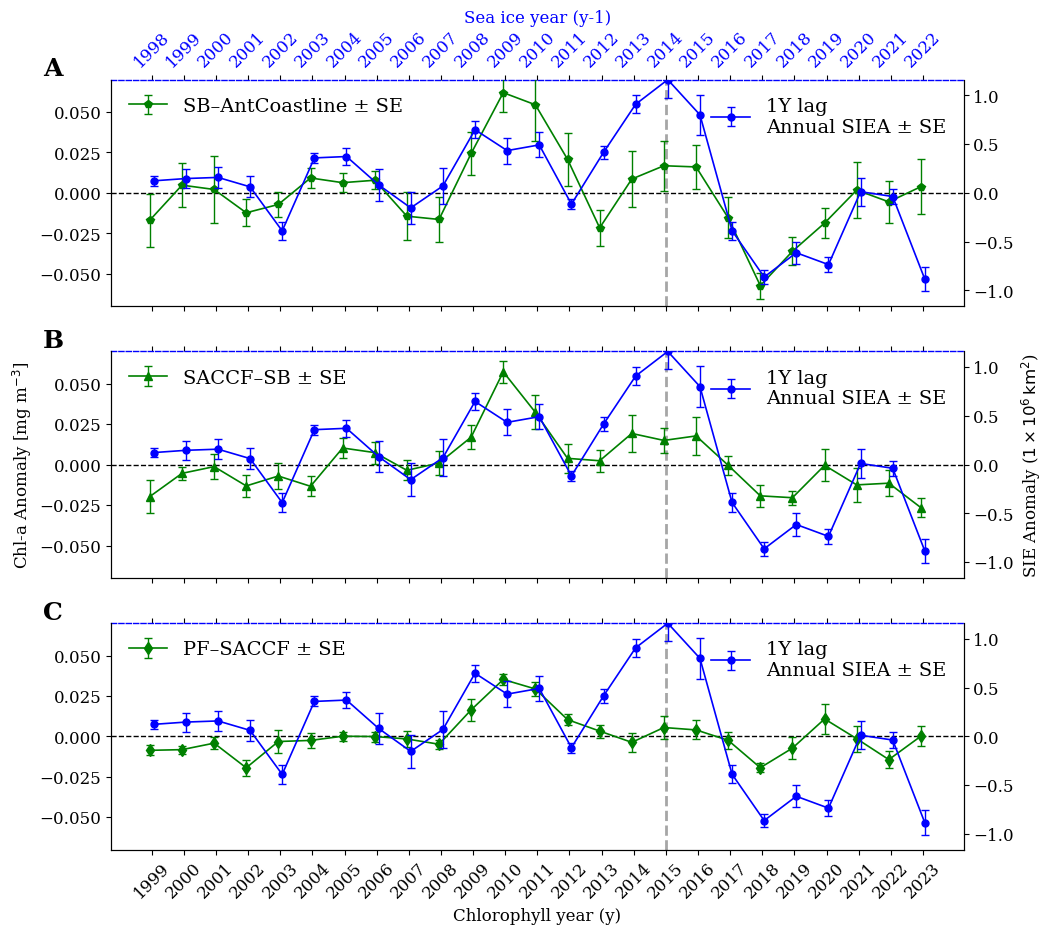

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =====================================================
# FIGURE SETUP
# =====================================================
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharey=True, sharex=True)

# Variables
anomaly_vars = ['SB_AntCoastline_ano', 'SACCF_SB_ano', 'PF_SACCF_ano']
colors = ['green', 'green', 'green']
markers = ['p', '^', 'd']
labels = ['SB–AntCoastline', 'SACCF–SB', 'PF–SACCF']
panel_labels = ['A', 'B', 'C']

# =====================================================
# STANDARD ERROR CALCULATION
# =====================================================
chl_std_raw = chl.resample('YE').std()
chl_count = chl.resample('YE').count()
chl_se_raw = chl_std_raw / np.sqrt(chl_count)
chl_se_raw.index = chl_se_raw.index.year

sie_std_raw = sie.resample('YE').std()
sie_count = sie.resample('YE').count()
sie_se_raw = sie_std_raw / np.sqrt(sie_count)
sie_se_raw.index = sie_se_raw.index.year

x_offset = pd.Timedelta(days=22)

# =====================================================
# PLOTTING LOOP
# =====================================================
for i, (ax, anomaly_var, color, marker, label, panel_label) in enumerate(
        zip(axes, anomaly_vars, colors, markers, labels, panel_labels)):

    # -------------------------------------------------
    # CHL-A with error bars
    # -------------------------------------------------
    chl_err = chl_annual_1.index.year.to_series().map(chl_se_raw.get(anomaly_var, np.nan))
    
    ax.errorbar(
        chl_annual_1.index - x_offset,
        chl_annual_1[anomaly_var],
        yerr=chl_err.values,
        marker=marker,
        linestyle='-',
        color=color,
        linewidth=1.2,
        capsize=3,
        elinewidth=1,
        capthick=1,
        label=f'{label} ± SE',
        zorder=3
    )
    ax.set_ylim(-0.07, 0.07)
    ax.text(-0.08, 1.05, panel_label, transform=ax.transAxes, 
            fontsize=18, fontweight='bold', va='center')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.axvline(x=pd.to_datetime('2015-12-31'), color='grey', 
               linestyle='--', linewidth=2, alpha=0.7)
    ax.spines['top'].set_visible(False)

    # -------------------------------------------------
    # SIE with error bars — YEAR-BASED ALIGNMENT
    # -------------------------------------------------
    ax2 = ax.twinx()
    common_idx = chl_annual_1.index
    
    # Align by YEAR (this is the key fix)
    sie_values = df_annual_1['SIEA_shifted'].copy()
    sie_values.index = sie_values.index.year
    sie_values = sie_values.reindex(common_idx.year)
    sie_values.index = common_idx  # restore datetime index for plotting
    
    sie_err = common_idx.year.to_series().map(sie_se_raw.get('SIEA', np.nan))
    
    # Plot (matplotlib skips NaNs automatically)
    ax2.errorbar(
        common_idx + x_offset,
        sie_values,
        yerr=sie_err.values,
        color='blue',
        marker='o',
        linestyle='-',
        linewidth=1.2,
        markersize=5,
        capsize=3,
        elinewidth=1,
        capthick=1,
        label='1Y lag\nAnnual SIEA ± SE',
        zorder=3
    )

    ax2.spines['top'].set_visible(False)
    # -------------------------------------------------
    # ZERO ALIGNMENT
    # -------------------------------------------------
    left_min, left_max = ax.get_ylim()
    zero_fraction = (0 - left_min) / (left_max - left_min) if left_max != left_min else 0.5
    zero_fraction = float(np.clip(zero_fraction, 1e-6, 1 - 1e-6))
    
    right_data = sie_values.to_numpy(dtype=float)
    right_data = right_data[np.isfinite(right_data)]
    
    if right_data.size:
        right_min = np.nanmin(right_data)
        right_max = np.nanmax(right_data)
        span = max(right_max / (1 - zero_fraction), -right_min / zero_fraction)
        if not np.isfinite(span) or span == 0:
            span = max(abs(right_min), abs(right_max), 1.0)
        ax2.set_ylim(-zero_fraction * span, (1 - zero_fraction) * span)

    # Labels
    if i == 1:
        ax.set_ylabel('Chl-a Anomaly [mg m$^{-3}$]')
        ax2.set_ylabel(r'SIE Anomaly ($1 \times 10^6 \, \mathrm{km}^2$)')

    ax.legend(loc='upper left', fontsize=14, frameon=False)
    ax2.legend(loc='upper right', fontsize=14, frameon=False)

    # Top X-axis (Sea ice year)
    ax_top = ax.secondary_xaxis('top')
    ax_top.set_xticks(common_idx)
    ax_top.set_xticklabels([str(year - 1) for year in common_idx.year], 
                           rotation=45, color='blue')
    ax_top.spines['top'].set_linestyle('--')
    ax_top.spines['top'].set_color('blue')
    ax_top.spines['top'].set_linewidth(1.0)
    ax_top.tick_params(axis='x', labelcolor='blue')
    
    if i == 0:
        ax_top.set_xlabel('Sea ice year (y-1)', color='blue')
    else:
        ax_top.set_xlabel('')
        ax_top.tick_params(labeltop=False)

    # Bottom x-axis
    ax.set_xticks(common_idx)
    ax.set_xticklabels(common_idx.year, rotation=45)
# Final label
axes[-1].set_xlabel('Chlorophyll year (y)')
plt.savefig("/A04/so_data/ubuntu/Chapter_2/Figures_GRL/Figure_3.png", dpi=300, bbox_inches='tight')
plt.show()
plt.tight_layout()
plt.show()

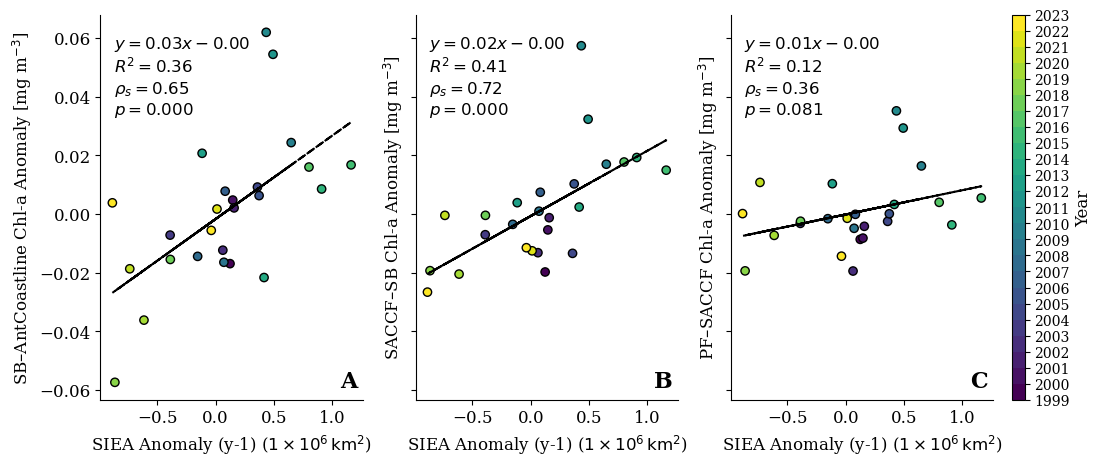

\nSpearman rank correlation results:
SB–AntCoastline: ρs = 0.649, p-value = 0.000
SACCF–SB: ρs = 0.718, p-value = 0.000
PF–SACCF: ρs = 0.356, p-value = 0.081


In [20]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import statsmodels.api as sm  # For p-value calculation
from scipy.stats import spearmanr  # Import Spearman correlation
import matplotlib.colors as mcolors

# Set global font to serif
plt.rcParams["font.family"] = "serif"

# Define the columns for anomalies and their labels/colors
anomaly_vars = ['SB_AntCoastline_ano', 'SACCF_SB_ano', 'PF_SACCF_ano']
colors = ['purple', 'green', 'red']
labels = ['SB–AntCoastline', 'SACCF–SB', 'PF–SACCF']
panel_labels = ['A', 'B', 'C']  # Panel labels for the three subplots

# Create subplots for each scatter plot
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

# Get years for discrete legend
# Get unique years for discrete colormap
years = df_annual_1.index.year
unique_years = np.unique(years)
cmap = plt.cm.viridis
norm = mcolors.BoundaryNorm(unique_years, cmap.N)

# Loop over each anomaly and plot with regression line
for ax, anomaly_var, label, panel_label in zip(axes, anomaly_vars, labels, panel_labels):
    # Add panel label in upper left corner
    ax.text(0.98, 0.02, panel_label, transform=ax.transAxes, fontsize=16, 
            fontweight='bold', va='bottom', ha='right')
    
    # Scatter plot with colors based on year
    sc = ax.scatter(df_annual_1['SIEA_shifted'], chl_annual_1[anomaly_var], 
                    c=years, cmap=cmap, norm=norm, edgecolor='black')

    # Perform linear regression
    X = df_annual_1['SIEA_shifted'].values.reshape(-1, 1)  # SIEA as x-variable
    y = chl_annual_1[anomaly_var].values  # Chl-a anomaly as y-variable
    
    # Check for non-NaN values
    mask = ~np.isnan(X.flatten()) & ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]
    
    # Fit linear regression using sklearn
    model = LinearRegression()
    model.fit(X_clean, y_clean)
    y_pred = model.predict(X_clean)
    
    # Fit linear regression using statsmodels for p-value calculation
    X_with_const = sm.add_constant(X_clean)  # Add constant term for intercept
    sm_model = sm.OLS(y_clean, X_with_const).fit()
    p_value = sm_model.pvalues[1]  # Extract p-value for the slope
    
    # CHANGED: Calculate Spearman rank correlation coefficient instead of Pearson
    rho_spearman, p_spearman = spearmanr(X_clean.flatten(), y_clean)

    # Get regression equation
    a = model.coef_[0]
    b = model.intercept_

    # Plot regression line
    ax.plot(X_clean, y_pred, color='k', linestyle='--')
    
    # Calculate and display R² value
    r2 = r2_score(y_clean, y_pred)
    
    # Display equation, R², p-value, and Spearman correlation coefficient (ρ)
    ax.text(0.05, 0.95, f'$y = {a:.2f}x {b:+.2f}$\n$R^2 = {r2:.2f}$\n$\\rho_s = {rho_spearman:.2f}$\n$p = {p_spearman:.3f}$', 
            transform=ax.transAxes, verticalalignment='top', color='k')
    
    # Set plot labels
    ax.set_xlabel('SIEA Anomaly (y-1) ($1 \\times 10^6 \\, \\mathrm{km}^2$)')
    ax.set_ylabel(f'{label} Chl-a Anomaly [mg m$^{{-3}}$]')

    # Remove box frame but keep x and y axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Add a discrete legend for years (only on the first subplot)
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, aspect=30)
cbar.set_label('Year')
cbar.set_ticks(unique_years)  # Ensure discrete year labels
cbar.ax.tick_params(labelsize=10)

# Plot formatting and spacing
#plt.tight_layout()
plt.savefig("/A04/so_data/ubuntu/Chapter_2/Figures_GRL/Figure_4.png", dpi=300, bbox_inches='tight')
plt.show()

print("\\nSpearman rank correlation results:")
# Calculate and print Spearman correlations for all regions
for var, label in zip(anomaly_vars, labels):
    X = df_annual_1['SIEA_shifted'].values
    y = chl_annual_1[var].values
    mask = ~np.isnan(X) & ~np.isnan(y)
    rho, p = spearmanr(X[mask], y[mask])
    print(f"{label}: ρs = {rho:.3f}, p-value = {p:.3f}")